# Movie Genre Classification

Developed a Movie Genre Classification model using NLP and Machine Learning. Movie plot summaries were preprocessed and transformed into TF-IDF features before training Logistic Regression, LinearSVC, Random Forest, and Multinomial Naive Bayes models. The best-performing model was selected based on classification metrics and saved along with the TF-IDF vectorizer for future genre prediction.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## 2. Load data

In [2]:
train_data = pd.read_csv('train_data.txt', sep=":::", header=None, engine="python")
test_data = pd.read_csv('test_data.txt', sep=":::", header=None, engine="python")


In [3]:
train = train_data.copy()
test = test_data.copy()


In [4]:
train = train.rename(columns={0:"Id",1:"Title",2:"Genre",3:"Description"})
test = test.rename(columns={0:"Id",1:"Title",2:"Description"})


In [5]:
for col in ["Title", "Genre", "Description"]:
    if col in train.columns:
        train[col] = train[col].astype(str).str.strip()

for col in ["Title", "Description"]:
    if col in test.columns:
        test[col] = test[col].astype(str).str.strip()


In [6]:
train.head()


,Id,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [7]:
test.head()


,Id,Title,Description
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apart..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty chi..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family o...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with his..."
4,5,Er nu zhai (1955),Before he was known internationally as a marti...


In [8]:
train["Full"] = train["Title"] + " " + train["Description"]
test["Full"] = test["Title"] + " " + test["Description"]


In [9]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Id           54214 non-null  int64 
 1   Title        54214 non-null  object
 2   Genre        54214 non-null  object
 3   Description  54214 non-null  object
 4   Full         54214 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [10]:
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54200 entries, 0 to 54199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Id           54200 non-null  int64 
 1   Title        54200 non-null  object
 2   Description  54200 non-null  object
 3   Full         54200 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [11]:
print(train.isna().sum())
print(test.isna().sum())


Id             0
Title          0
Genre          0
Description    0
Full           0
dtype: int64
Id             0
Title          0
Description    0
Full           0
dtype: int64


In [12]:
print(train.duplicated().sum())
print(test.duplicated().sum())


0
0


## 3. Text cleaning

In [13]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re


In [14]:
stopword = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [15]:
def clean_text(x):
    x = x.lower()
    x = re.sub(r'[^a-zA-Z\s]', ' ', x)
    x = x.strip()
    x = x.split()
    x = [word for word in x if word not in stopword]
    x = [lemmatizer.lemmatize(word) for word in x]
    return " ".join(x)


In [16]:
train["Full"] = train["Full"].apply(clean_text)
test["Full"] = test["Full"].apply(clean_text)


## 4. EDA

**Visual 1 — genre counts.**

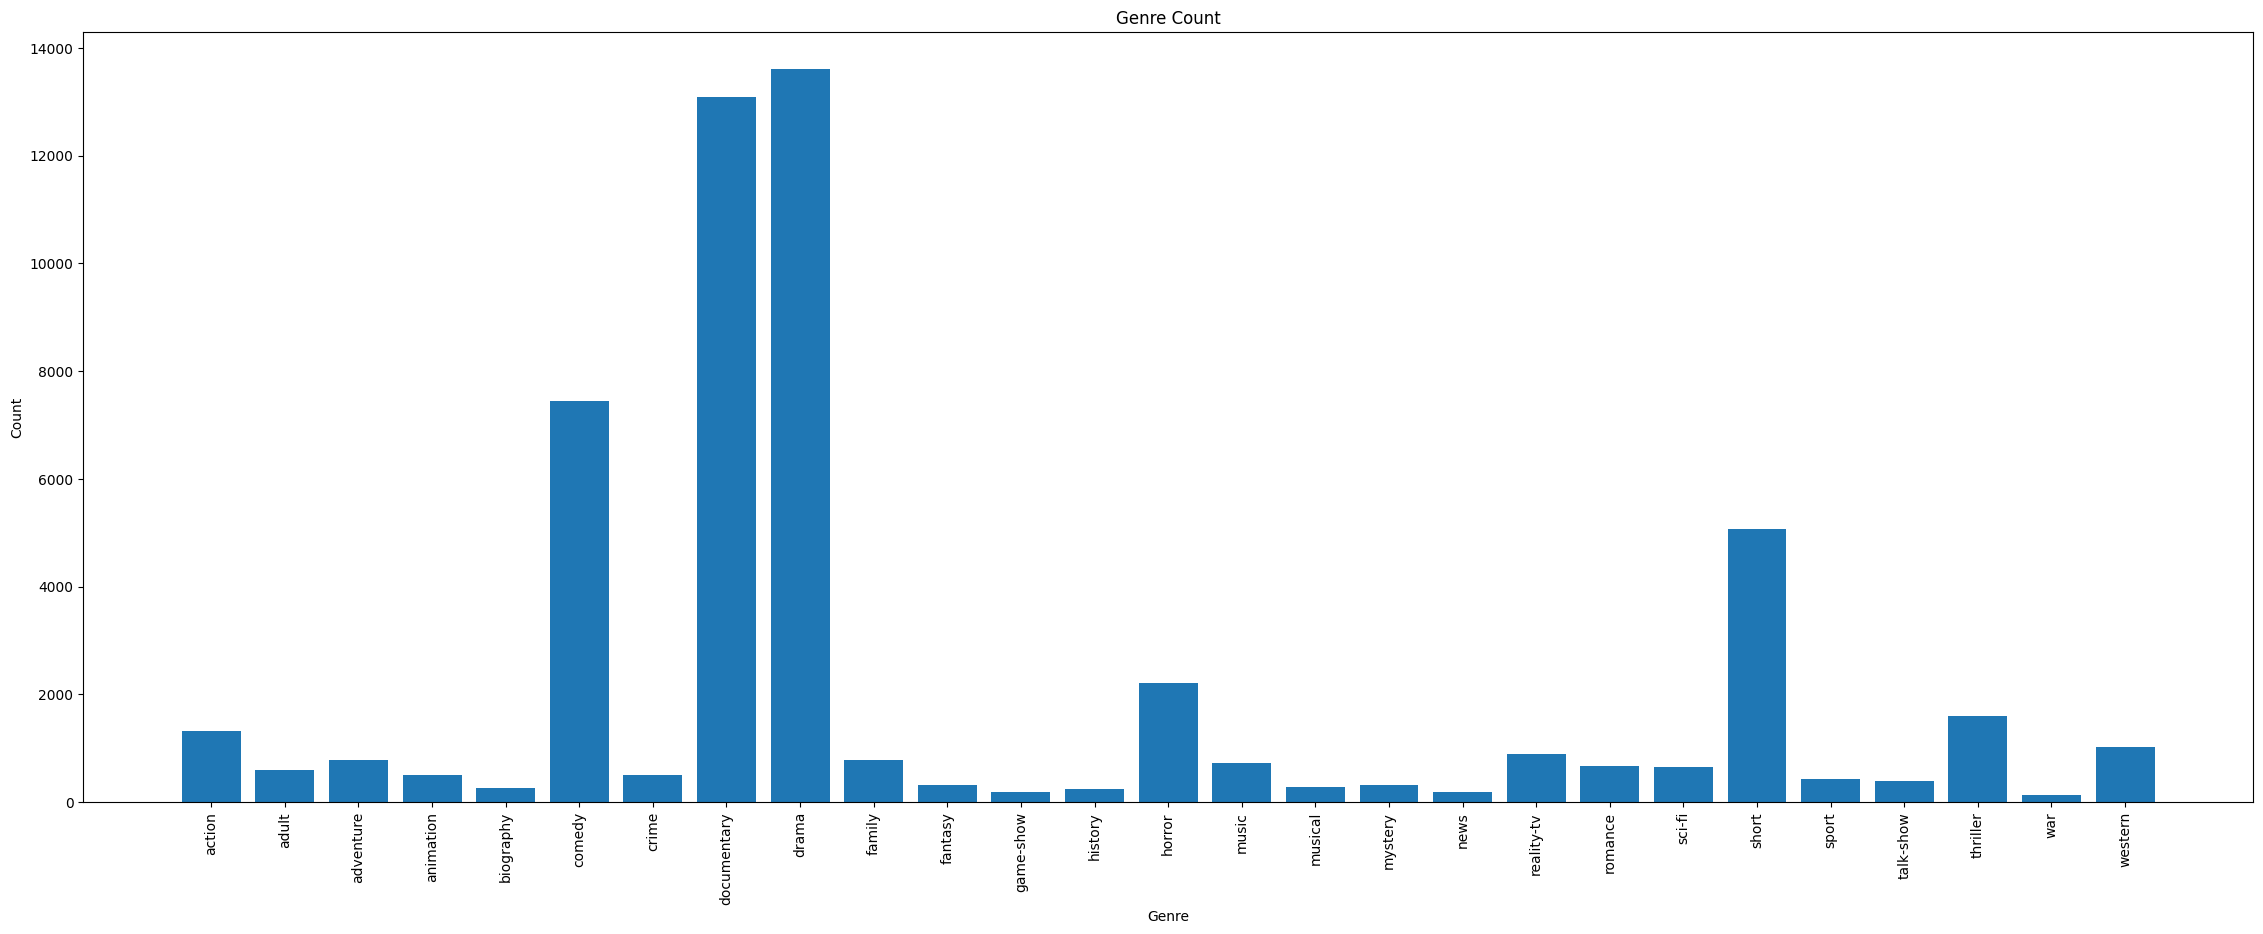

In [17]:
genre_count = train["Genre"].value_counts().sort_index()
plt.figure(figsize=(28,10))
plt.title("Genre Count")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.bar(genre_count.index, genre_count.values)
plt.xticks(rotation=90)
plt.show()


**Visual 2 — description length distribution.**

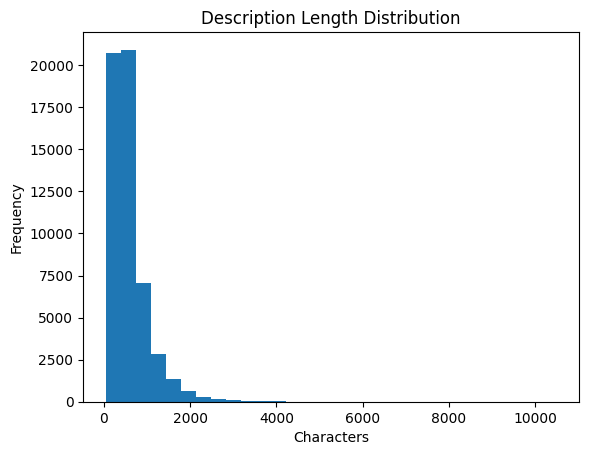

In [18]:
train["desc_length"] = train["Description"].apply(len)

plt.hist(train["desc_length"], bins=30)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Description Length Distribution")
plt.show()


**Visual 3 — word cloud of raw descriptions.**

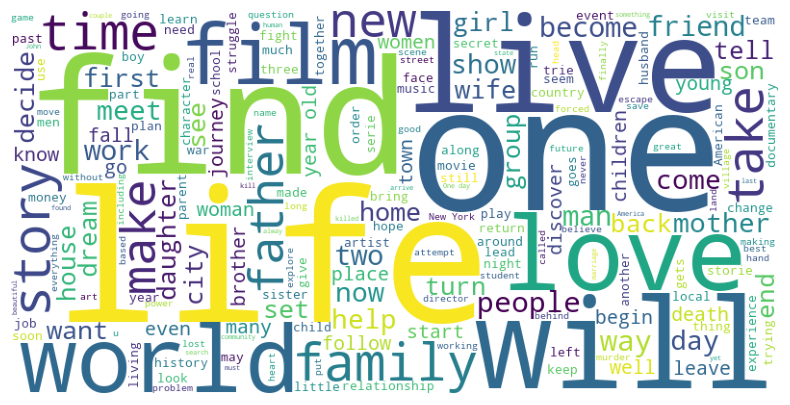

In [19]:
from wordcloud import WordCloud

text = " ".join(train["Description"])

wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()


**Visual 4 — most frequent words.**

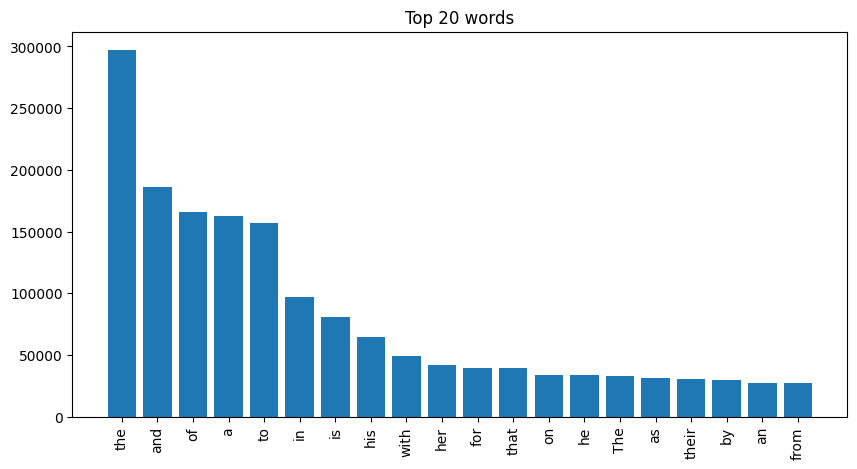

In [20]:
from collections import Counter

words = " ".join(train["Description"]).split()
counter = Counter(words)
top = counter.most_common(20)
word, freq = zip(*top)
plt.figure(figsize=(10,5))
plt.bar(word, freq)
plt.xticks(rotation=90)
plt.title("Top 20 words")
plt.show()


**Visual 5 — word count distribution.**

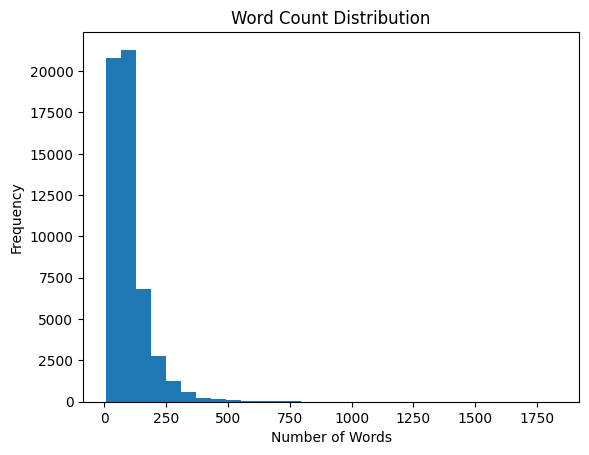

In [21]:
train["word_count"] = train["Description"].apply(lambda x: len(x.split()))

plt.hist(train["word_count"], bins=30)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.show()


## 5. Train/test split + TF-IDF

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


In [23]:
X = train["Full"]
y = train["Genre"]


In [24]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [25]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=10000)
tfidf_train_X = tfidf.fit_transform(train_X)
tfidf_test_X = tfidf.transform(test_X)


In [26]:
pd.DataFrame(tfidf_train_X[:5].toarray(), columns=tfidf.get_feature_names_out()).head()


,aaron,abandon,abandoned,abby,abc,abducted,abduction,abdul,abel,ability,...,zen,zen garden,zero,zhi,zi,zoe,zombie,zone,zoo,zu
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Models

### Logistic Regression

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(tfidf_train_X, train_y)
pred_lr = lr.predict(tfidf_test_X)
print("Classification Report:\n", classification_report(test_y, pred_lr))


Classification Report:
               precision    recall  f1-score   support

      action       0.34      0.48      0.39       263
       adult       0.37      0.72      0.49       118
   adventure       0.20      0.35      0.26       155
   animation       0.19      0.30      0.23       100
   biography       0.04      0.13      0.06        53
      comedy       0.61      0.45      0.52      1490
       crime       0.13      0.34      0.19       101
 documentary       0.79      0.56      0.65      2619
       drama       0.71      0.38      0.50      2723
      family       0.15      0.34      0.20       157
     fantasy       0.10      0.23      0.14        65
   game-show       0.66      0.74      0.70        39
     history       0.07      0.29      0.12        49
      horror       0.60      0.68      0.64       441
       music       0.38      0.75      0.50       146
     musical       0.12      0.25      0.16        55
     mystery       0.13      0.22      0.16        64
   

### Linear SVC

In [28]:
svc = LinearSVC(random_state=42, class_weight="balanced")
svc.fit(tfidf_train_X, train_y)
pred_svc = svc.predict(tfidf_test_X)
print("Classification Report:\n", classification_report(test_y, pred_svc))


Classification Report:
               precision    recall  f1-score   support

      action       0.31      0.46      0.37       263
       adult       0.38      0.65      0.48       118
   adventure       0.19      0.27      0.22       155
   animation       0.18      0.27      0.21       100
   biography       0.07      0.09      0.08        53
      comedy       0.58      0.50      0.53      1490
       crime       0.15      0.21      0.17       101
 documentary       0.76      0.71      0.73      2619
       drama       0.67      0.47      0.55      2723
      family       0.16      0.27      0.20       157
     fantasy       0.09      0.15      0.11        65
   game-show       0.60      0.64      0.62        39
     history       0.09      0.12      0.11        49
      horror       0.55      0.69      0.61       441
       music       0.43      0.66      0.52       146
     musical       0.17      0.24      0.20        55
     mystery       0.06      0.08      0.07        64
   

### Random Forest

In [29]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, max_samples=0.5, max_depth=30, n_estimators=100, class_weight="balanced")
rf.fit(tfidf_train_X, train_y)
pred_rf = rf.predict(tfidf_test_X)
print("Classification Report:\n", classification_report(test_y, pred_rf))


Classification Report:
               precision    recall  f1-score   support

      action       0.14      0.08      0.10       263
       adult       0.19      0.56      0.29       118
   adventure       0.32      0.18      0.23       155
   animation       0.11      0.16      0.13       100
   biography       0.03      0.02      0.02        53
      comedy       0.50      0.17      0.25      1490
       crime       0.11      0.40      0.17       101
 documentary       0.66      0.51      0.58      2619
       drama       0.47      0.26      0.34      2723
      family       0.05      0.03      0.03       157
     fantasy       0.03      0.05      0.04        65
   game-show       0.29      0.72      0.41        39
     history       0.05      0.14      0.07        49
      horror       0.32      0.36      0.34       441
       music       0.19      0.78      0.31       146
     musical       0.08      0.16      0.11        55
     mystery       0.08      0.08      0.08        64
   

### Multinomial Naive Bayes

In [30]:
nb = MultinomialNB()
nb.fit(tfidf_train_X, train_y)
pred_nb = nb.predict(tfidf_test_X)
print("Classification Report:\n", classification_report(test_y, pred_nb))


Classification Report:
               precision    recall  f1-score   support

      action       0.59      0.04      0.07       263
       adult       0.50      0.04      0.08       118
   adventure       0.88      0.05      0.09       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.43      0.47      1490
       crime       0.00      0.00      0.00       101
 documentary       0.56      0.89      0.69      2619
       drama       0.45      0.83      0.59      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.03      0.05        39
     history       0.00      0.00      0.00        49
      horror       0.80      0.29      0.43       441
       music       1.00      0.01      0.03       146
     musical       0.00      0.00      0.00        55
     mystery       0.00      0.00      0.00        64
   

## 7. Model comparison

Macro-averaged metrics since this is multiclass with many genres of uneven size.

In [31]:
models = {
    "Logistic Regression": (lr, pred_lr),
    "Linear SVC": (svc, pred_svc),
    "Random Forest": (rf, pred_rf),
    "Multinomial NB": (nb, pred_nb),
}

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

comparison = pd.DataFrame({
    name: get_metrics(test_y, pred) for name, (model, pred) in models.items()
}).T

comparison


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Logistic Regression,0.473577,0.324214,0.473232,0.363247
Linear SVC,0.515817,0.323194,0.404578,0.352884
Random Forest,0.323066,0.198197,0.333000,0.215625
Multinomial NB,0.516739,0.366058,0.120273,0.127202


**Visual 6 — model comparison chart.**

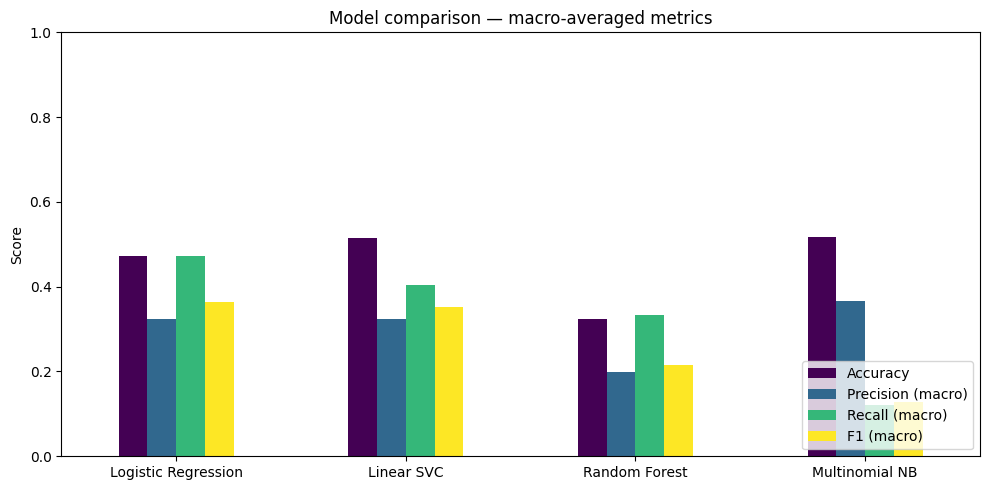

In [32]:
comparison.plot(kind="bar", figsize=(10,5), colormap="viridis")
plt.title("Model comparison — macro-averaged metrics")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 8. Select best model and predict on the test set

In [33]:
best_model_name = comparison["F1 (macro)"].idxmax()
best_model = models[best_model_name][0]
print("Best model:", best_model_name)


Best model: Logistic Regression


In [34]:
tfidf_full_test = tfidf.transform(test["Full"])
test_predictions = best_model.predict(tfidf_full_test)

submission = pd.DataFrame({
    "Id": test["Id"],
    "Title": test["Title"],
    "Predicted_Genre": test_predictions
})

submission.head()


,Id,Title,Predicted_Genre
0,1,Edgar's Lunch (1998),comedy
1,2,La guerra de papá (1977),drama
2,3,Off the Beaten Track (2010),documentary
3,4,Meu Amigo Hindu (2015),drama
4,5,Er nu zhai (1955),drama


In [35]:
submission.to_csv("genre_predictions.csv", index=False)
print("Saved genre_predictions.csv")


Saved genre_predictions.csv


## 9. Saving model

In [36]:
import joblib

joblib.dump(best_model, "movie_genre_model.pkl")
joblib.dump(tfidf, "tfidf_vect.pkl")

print(f"Saved {best_model_name} and TF-IDF vectorizer.")


Saved Logistic Regression and TF-IDF vectorizer.
